# CarDD — EDA d'inspection (candidat `cardd`, format COCO officiel)

**Gate EDA** : on inspecte, on chiffre, **on s'arrête**. Décision consignée en ADR 0006.

**Provenance** : CarDD officiel (USTC, IEEE T-ITS 2023), Google Drive → `CarDD_release/CarDD_COCO`.
Format **COCO** (boîtes + masques), splits officiels **train/val/test**. Images Flickr/Shutterstock.
**Licence recherche/éducation non commerciale** → OK BC04, non republié (`dl/data/**` gitignored).

In [1]:
import json
from pathlib import Path
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

COCO = Path('../../data/cardd/raw/CarDD_release/CarDD_COCO')
SPLITS = {'train': 'train2017', 'val': 'val2017', 'test': 'test2017'}

data = {s: json.load(open(COCO / 'annotations' / f'instances_{SPLITS[s]}.json')) for s in SPLITS}
CATS = {c['id']: c['name'] for c in data['train']['categories']}
print('classes :', list(CATS.values()))
for s in SPLITS:
    print(f'{s:5s}: {len(data[s]["images"]):5d} images, {len(data[s]["annotations"]):5d} instances')

classes : ['dent', 'scratch', 'crack', 'glass shatter', 'lamp broken', 'tire flat']
train:  2816 images,  6211 instances
val  :   810 images,  1744 instances
test :   374 images,   785 instances


In [2]:
# --- Multi-label : quelles classes présentes par image, par split ---
def per_image_labels(d):
    lab = defaultdict(set)
    for a in d['annotations']:
        lab[a['image_id']].add(CATS[a['category_id']])
    return lab

rows = {}
for s in SPLITS:
    lab = per_image_labels(data[s])
    rows[s] = {c: sum(1 for v in lab.values() if c in v) for c in CATS.values()}
img_by_class = pd.DataFrame(rows)
img_by_class['total'] = img_by_class.sum(axis=1)
img_by_class = img_by_class.sort_values('total', ascending=False)
print('IMAGES par classe et par split :')
print(img_by_class)
print('\ndesequilibre (images, train) max/min :',
      round(rows['train'][img_by_class.index[0]] / rows['train'][img_by_class.index[-1]], 1), 'x')

IMAGES par classe et par split :
               train  val  test  total
scratch         1507  431   183   2121
dent            1242  352   157   1751
lamp broken      489  139    65    693
glass shatter    469  134    71    674
crack            434  122    48    604
tire flat        219   59    31    309

desequilibre (images, train) max/min : 6.9 x


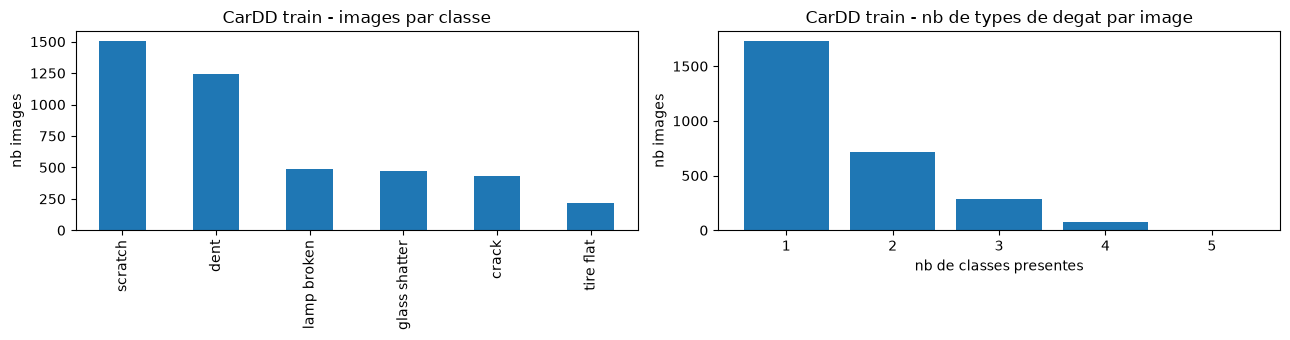

In [3]:
# --- Barplot images/classe (train) + nb de labels par image ---
fig, ax = plt.subplots(1, 2, figsize=(13, 3.5))
img_by_class['train'].plot.bar(ax=ax[0], title='CarDD train - images par classe')
ax[0].set_ylabel('nb images')
nlab = Counter(len(v) for v in per_image_labels(data['train']).values())
ax[1].bar(sorted(nlab), [nlab[k] for k in sorted(nlab)])
ax[1].set_title('CarDD train - nb de types de degat par image')
ax[1].set_xlabel('nb de classes presentes'); ax[1].set_ylabel('nb images')
plt.tight_layout(); plt.show()

            W       H      MP      KB
count  4000.0  4000.0  4000.0  4000.0
mean    978.1   706.2     0.7   756.8
std      79.6    97.9     0.1   185.1
min     562.0   333.0     0.3   178.3
25%    1000.0   667.0     0.7   632.7
50%    1000.0   667.0     0.7   745.9
75%    1000.0   750.0     0.7   871.3
max    1000.0  1000.0     1.0  1868.6

doublons (aHash exact, tous splits confondus) : 3


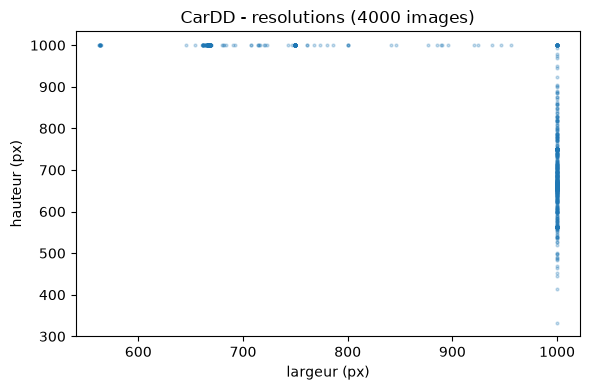

In [4]:
# --- Cote image : resolutions, poids, doublons (aHash) sur les 3 splits ---
def ahash(im, s=8):
    a = np.asarray(im.convert('L').resize((s, s)), dtype=np.float32)
    return (a > a.mean()).tobytes()

recs = []; hashes = Counter()
for s in SPLITS:
    for im_info in data[s]['images']:
        p = COCO / SPLITS[s] / im_info['file_name']
        with Image.open(p) as im:
            w, h = im.size
            hashes[ahash(im)] += 1
        recs.append((s, w, h, w * h / 1e6, p.stat().st_size / 1e3))
res = pd.DataFrame(recs, columns=['split', 'W', 'H', 'MP', 'KB'])
print(res[['W', 'H', 'MP', 'KB']].describe().round(1))
dups = sum(c - 1 for c in hashes.values() if c > 1)
print('\ndoublons (aHash exact, tous splits confondus) :', dups)
plt.figure(figsize=(6, 4))
plt.scatter(res['W'], res['H'], s=4, alpha=.25)
plt.xlabel('largeur (px)'); plt.ylabel('hauteur (px)')
plt.title('CarDD - resolutions (4000 images)'); plt.tight_layout(); plt.show()

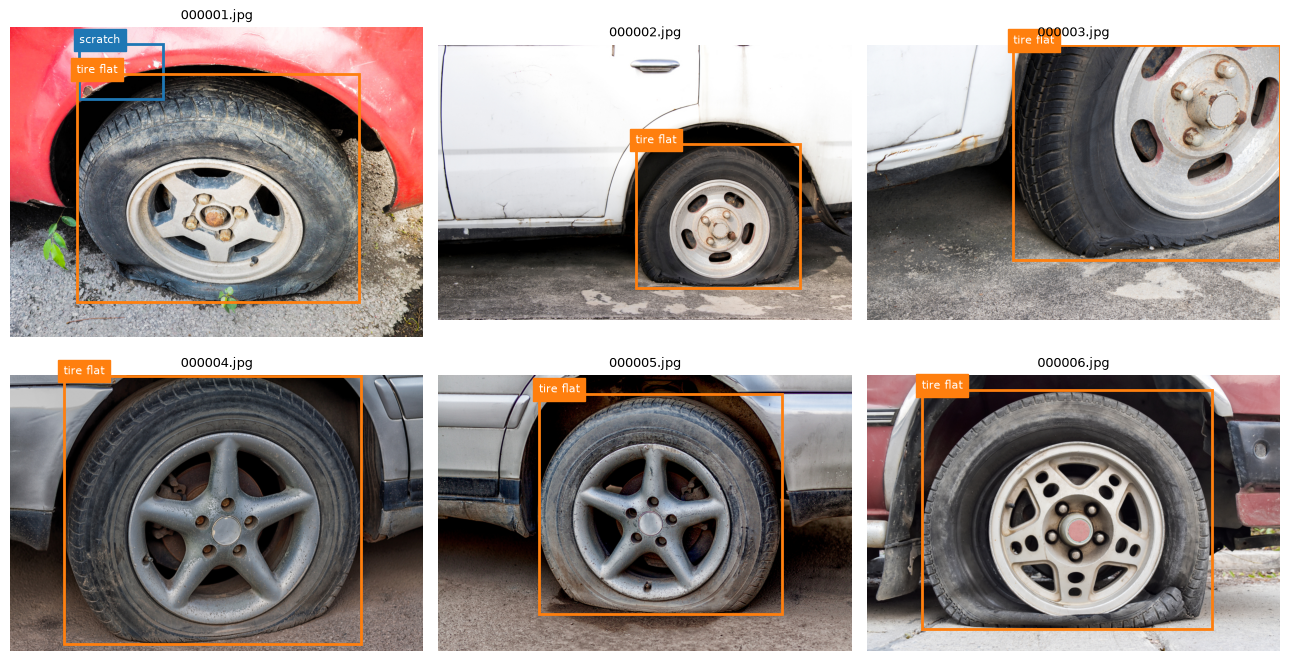

In [5]:
# --- Echantillons visuels avec boites (COCO bbox = [x,y,w,h] pixels absolus) ---
colors = {}; palette = plt.cm.tab10.colors
def col(name):
    colors.setdefault(name, palette[len(colors) % 10]); return colors[name]

d = data['train']
by_img = defaultdict(list)
for a in d['annotations']:
    by_img[a['image_id']].append(a)
info = {i['id']: i for i in d['images']}
sample_ids = list(by_img)[:6]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, iid in zip(axes.ravel(), sample_ids):
    im_info = info[iid]
    with Image.open(COCO / 'train2017' / im_info['file_name']) as im:
        ax.imshow(im)
    for a in by_img[iid]:
        x, y, bw, bh = a['bbox']
        name = CATS[a['category_id']]
        ax.add_patch(patches.Rectangle((x, y), bw, bh, fill=False, lw=2, edgecolor=col(name)))
        ax.text(x, y - 3, name, color='white', fontsize=8, backgroundcolor=col(name))
    ax.set_title(im_info['file_name'], fontsize=9); ax.axis('off')
plt.tight_layout(); plt.show()

## Synthèse (Gate → ADR 0006)

- **4000 images**, splits officiels **2816 / 810 / 374**, ~8740 instances, **6 classes**
  (dent, scratch, crack, glass shatter, lamp broken, tire flat).
- **0 image intacte** (toutes ont ≥1 dégât) → binaire intact/abîmé **infaisable** sur CarDD seul ;
  objectif retenu = **multi-label type de dégât** (une image porte 1-2 types en général).
- **Déséquilibre fort** (scratch ~7× tire flat au niveau image) → métriques par classe + pondération.
- **Résolution ~1000px** (l'officiel n'est pas plus haute réso que le mirror) → petits dégâts limités.
- **Biais de source** : photos stock "propres", pas des photos d'annonce → généralisation à mesurer.

**STOP** — décision consignée en `docs/decisions/0006-dataset-cardd-objectif-multilabel.md`.